In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [3]:
from cycler import cycler
import matplotlib.pyplot as plt

model_colors = {
    "Qwen/Qwen2.5-0.5B": "#59A14F",      # green
    "facebook/opt-1.3b": "#E15759",      # red
    "meta-llama/Llama-2-7b-hf": "#4E79A7",  # blue
    "tiiuae/falcon-7b": "#F28E2B",       # orange
    "mistralai/Mistral-7B-v0.1": "#76B7B2", # teal
    "google/gemma-2b": "#EDC948",        # yellow
    "google/gemma-2-2b": "#B07AA1",      # purple
    "microsoft/phi-2": "#FF9DA7"         # pink
}

In [13]:
csv_files = glob.glob("/kaggle/input/datasets/kabirvats/inp-len/*.csv")

In [14]:
plt.style.use("seaborn-v0_8-whitegrid")   # cleaner theme

plt.figure(figsize=(10,6), dpi=500)       # larger + high resolution

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "lines.linewidth": 2.5,
    "lines.markersize": 7
})

<Figure size 5000x3000 with 0 Axes>

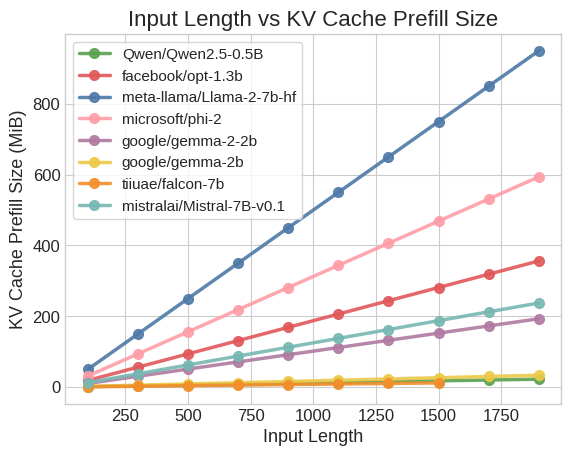

In [15]:
plt.figure()

for file in csv_files:
    df = pd.read_csv(file)

    # model_name is constant per CSV
    model_name = df["model_name"].iloc[0]

    x = df["x"]
    y = df["kv_prefill_mib"]

    plt.plot(x, y, marker="o", label=model_name, alpha=0.9,  color=model_colors[model_name])

plt.xlabel("Input Length")
plt.ylabel("KV Cache Prefill Size (MiB)")
plt.title("Input Length vs KV Cache Prefill Size")
plt.legend(frameon=True)
plt.grid(True)
plt.savefig("inp_vs_kv.png", dpi=300, bbox_inches="tight")
plt.show()

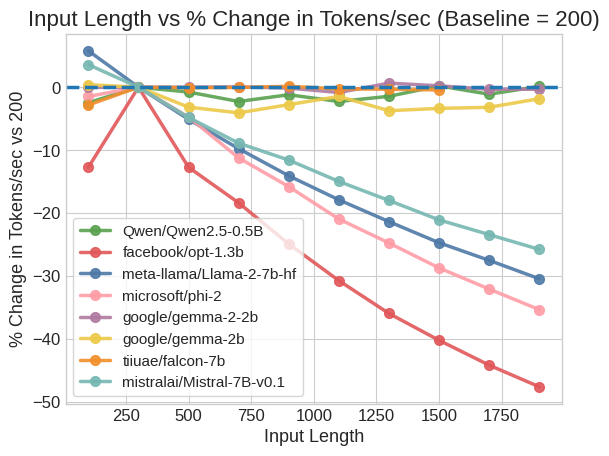

In [16]:
plt.figure()

for file in csv_files:
    df = pd.read_csv(file)

    model_name = df["model_name"].iloc[0]

    x = df["x"]
    y = df["tokens_per_sec"]

    baseline = y.iloc[1]  # tokens/sec at x = 100
    pct_change = ((y - baseline) / baseline) * 100

    plt.plot(x, pct_change, marker="o", label=model_name, alpha=0.9, color=model_colors[model_name])

plt.xlabel("Input Length")
plt.ylabel("% Change in Tokens/sec vs 200")
plt.title("Input Length vs % Change in Tokens/sec (Baseline = 200)")
plt.axhline(0, linestyle="--")
plt.legend(frameon=True)
plt.grid(True)

plt.savefig("inp_vs_speed.png", dpi=300, bbox_inches="tight")

plt.show()

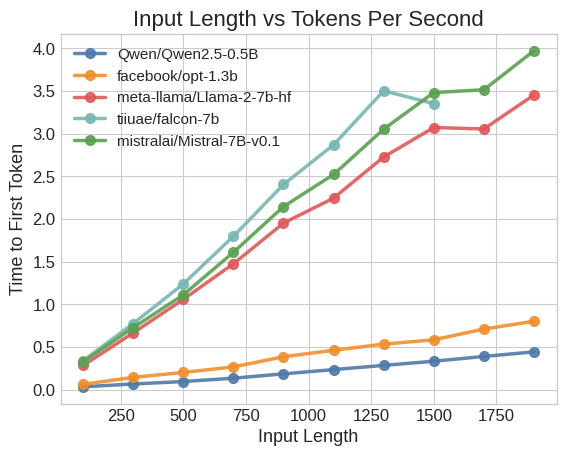

In [39]:
plt.figure()

for file in csv_files:
    df = pd.read_csv(file)

    # model_name is constant per CSV
    model_name = df["model_name"].iloc[0]

    x = df["x"]
    y = df["ttft_sec"]

    plt.plot(x, y, marker="o", label=model_name, alpha=0.9)

plt.xlabel("Input Length")
plt.ylabel("Time to First Token")
plt.title("Input Length vs Tokens Per Second")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
csv_files = glob.glob("/kaggle/input/datasets/kabirvats/max-new-tok/*.csv")

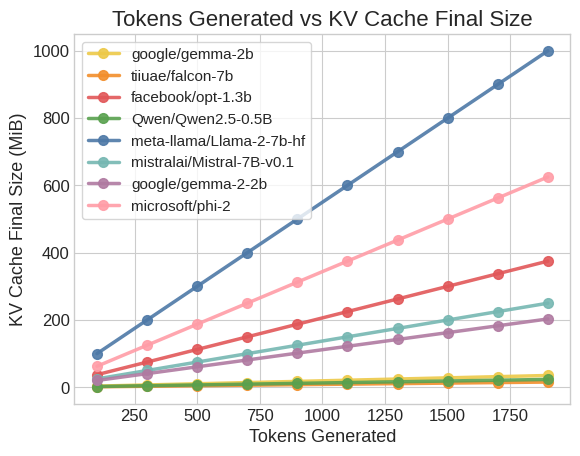

In [9]:
plt.figure()

for file in csv_files:
    df = pd.read_csv(file)

    # model_name is constant per CSV
    model_name = df["model_name"].iloc[0]

    x = df["x"]
    y = df["kv_final_mib"]

    plt.plot(x, y, marker="o", label=model_name, alpha=0.9, color=model_colors[model_name])

plt.xlabel("Tokens Generated")
plt.ylabel("KV Cache Final Size (MiB)")
plt.title("Tokens Generated vs KV Cache Final Size")
plt.legend(frameon=True)
plt.grid(True)

plt.savefig("gen_vs_kv.png", dpi=300, bbox_inches="tight")

plt.show()

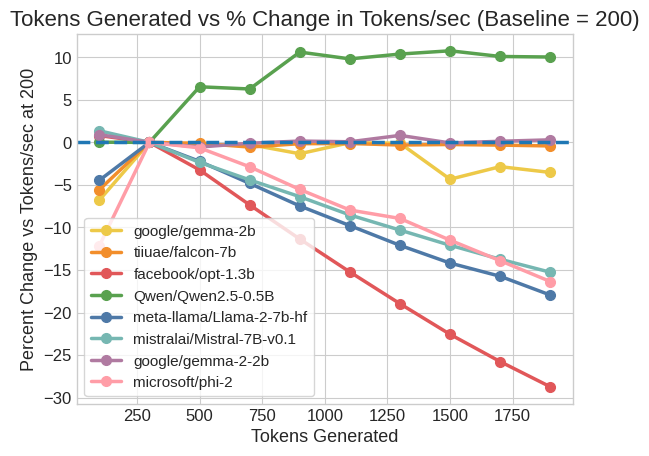

In [12]:
plt.figure()

for file in csv_files:
    df = pd.read_csv(file)

    model_name = df["model_name"].iloc[0]

    x = df["x"]
    y = df["tokens_per_sec"]

    baseline = y.iloc[1]  # tokens/sec at x = 100
    pct_change = ((y - baseline) / baseline) * 100

    plt.plot(x, pct_change, marker="o", label=model_name, color=model_colors[model_name])

plt.xlabel("Tokens Generated")
plt.ylabel("Percent Change vs Tokens/sec at 200")
plt.title("Tokens Generated vs % Change in Tokens/sec (Baseline = 200)")
plt.axhline(0, linestyle="--")
plt.legend(frameon=True)
plt.grid(True)

plt.savefig("gen_vs_speed.png", dpi=300, bbox_inches="tight")

plt.show()